In [ ]:
import numpy as np
import pandas as pd

In [ ]:
pub1 = np.ones(17).tolist()

In [ ]:
pub1 = np.random.rand(17).tolist()
pub1

[0.3165794559236699,
 0.6606572250642769,
 0.5217736472248115,
 0.3355571925918389,
 0.13369599193210713,
 0.48351173583997753,
 0.9078118360414676,
 0.42478601175590736,
 0.8847358764768378,
 0.18331059896979018,
 0.5694646129282523,
 0.9894812840563191,
 0.39324376591189414,
 0.4600025582328032,
 0.10116065228310345,
 0.2916807426644986,
 0.45870932592417324]

In [ ]:
# Define SDG-related colors (using approximate hex colors for SDG targets)
sdg_colors = [
    '#E5243B',  # SDG 1: No Poverty
    '#DDA63A',  # SDG 2: Zero Hunger
    '#4C9F38',  # SDG 3: Good Health and Well-being
    '#C5192D',  # SDG 4: Quality Education
    '#FF3A21',  # SDG 5: Gender Equality
    '#26BDE2',  # SDG 6: Clean Water and Sanitation
    '#FCC30B',  # SDG 7: Affordable and Clean Energy
    '#A21942',  # SDG 8: Decent Work and Economic Growth
    '#FD6925',  # SDG 9: Industry, Innovation and Infrastructure
    '#DD1367',  # SDG 10: Reduced Inequality
    '#FD9D24',  # SDG 11: Sustainable Cities and Communities
    '#BF8B2E',  # SDG 12: Responsible Consumption and Production
    '#3F7E44',  # SDG 13: Climate Action
    '#0A97D9',  # SDG 14: Life Below Water
    '#56C02B',  # SDG 15: Life on Land
    '#00689D',  # SDG 16: Peace, Justice and Strong Institutions
    '#19486A'   # SDG 17: Partnerships for the Goals
]

def radar_chart_with_sdg_colors(values, labels, title="SDG Radar Chart"):
    """
    Generates a radar chart with bars colored according to the SDG-related colors.

    :param values: List or array of 17 values representing the data to plot.
    :param labels: List of 17 strings representing the labels for each axis.
    :param title: Title of the radar chart.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Number of variables (in this case, it should always be 17)
    num_vars = len(values)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Complete the loop for the radar chart
    values += values[:1]
    angles += angles[:1]

    # Create polar plot
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Plot data
    ax.fill(angles, values, 'b', alpha=0.1)
    ax.plot(angles, values, 'b', linewidth=1)

    # Add labels to each axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    # Set the title
    ax.set_title(title, size=15, color='black')

    # Add colored bars corresponding to SDG colors
    for i, angle in enumerate(angles[:-1]):
        ax.bar(angle, values[i], color=sdg_colors[i], alpha=0.6, width=0.15)

    # Show the radar chart
    plt.show()




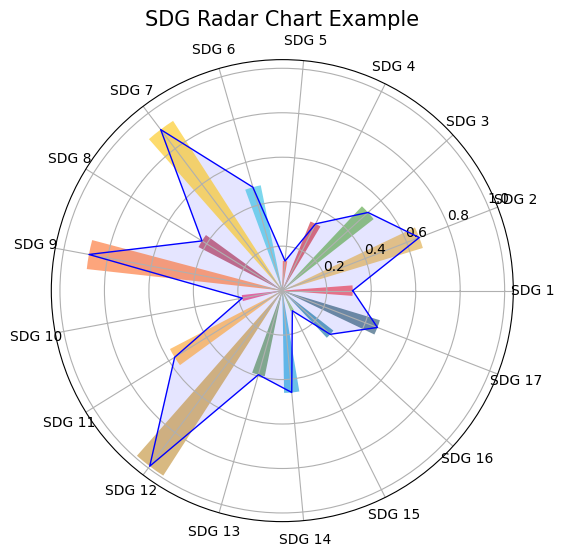

In [ ]:
labels = [f'SDG {i+1}' for i in range(17)]
radar_chart_with_sdg_colors(pub1, labels, title="SDG Radar Chart Example")


In [ ]:
def sdg_barchart(values, labels, title="SDG Bar Chart"):
    """
    Generates a bar chart with bars colored according to the SDG-related colors.

    :param values: List or array of 17 values representing the data to plot.
    :param labels: List of 17 strings representing the labels for each axis.
    :param title: Title of the bar chart.
    """
    import matplotlib.pyplot as plt

    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars with SDG colors
    print(len(labels), len(values), len(sdg_colors))
    bars = ax.bar(labels, values, color=sdg_colors, alpha=0.8)

    # Set chart title and labels
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('SDG Targets', fontsize=12)
    ax.set_ylabel('Values', fontsize=12)
    ax.set_xticklabels(labels, rotation=45, ha='right')

    # Show the bar chart
    plt.tight_layout()
    plt.show()

17 18 17


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (17,) and arg 1 with shape (18,).

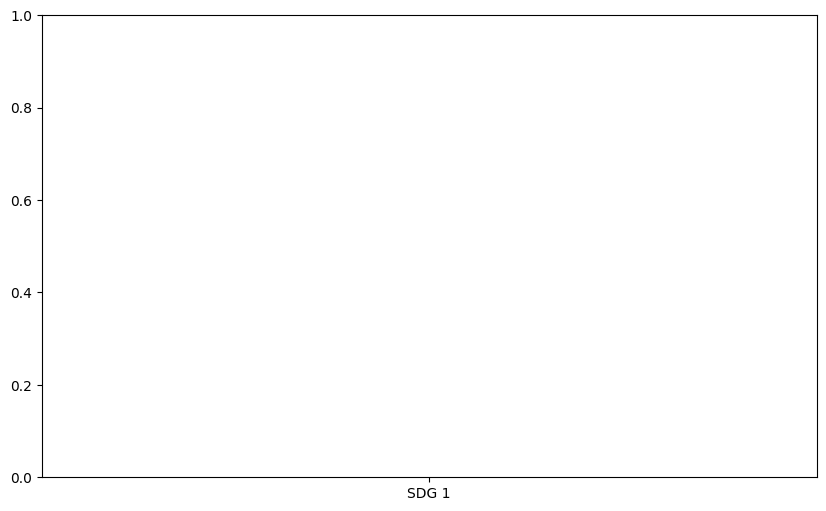

In [ ]:
sdg_barchart(pub1, labels, title="SDG Radar Chart Example")

In [ ]:
def sdg_glyph_optimized(values, labels, title="SDG Glyph with Saturation and Outline"):
    """
    Generates a circular glyph where each segment corresponds to an SDG and is colored based on the prediction value,
    with an outline connecting the concrete values in a radar chart style.

    :param values: List or array of values representing the data to plot.
    :param labels: List of strings representing the labels for each axis (SDG names).
    :param title: Title of the glyph.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Wedge
    from matplotlib.colors import to_rgba

    # Number of variables (SDGs)
    num_vars = len(values)

    # Compute the angle for each segment
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Shift angles to target the center of each segment (for contour alignment)
    middle_angles = [(angles[i] + (angles[i+1] if i+1 < num_vars else 2 * np.pi)) / 2 for i in range(num_vars)]

    # Complete the loop for the radar-like outline
    values_with_loop = values + [values[0]]
    #angles_with_loop = angles + [angles[0]]
    angles_with_loop = middle_angles + [middle_angles[0]]

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'aspect': 'equal'})

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Draw each SDG segment with saturation based on value
    for i, val in enumerate(values):
        base_color = np.array(to_rgba(sdg_colors[i]))  # Get RGBA values of the SDG color
        white_color = np.array([1, 1, 1, 1])  # Pure white color
        # Linearly interpolate between white and the SDG color based on the value
        saturated_color = white_color * (1 - val) + base_color * val  # Interpolate between white and base color
        ax.add_patch(Wedge((0, 0), 1, np.degrees(angles[i]), np.degrees(angles[i+1] if i+1 < num_vars else 0),
                           color=saturated_color))

        # Add text (prediction values) into the segment, shift text inward slightly
        text_angle = (angles[i] + (angles[i+1] if i+1 < num_vars else 2*np.pi)) / 2
        ax.text(np.cos(text_angle) * 0.5, np.sin(text_angle) * 0.5,
                f"{values[i]:.2f}", color="black", ha='center', va='center', fontsize=10)

        # Add SDG labels closer to the segment (reduced distance)
        ax.text(np.cos(middle_angles[i]) * 1.3, np.sin(middle_angles[i]) * 1.3,
                f"{labels[i]}: {values[i]:.2f}", color="black", ha='center', va='center', fontsize=11)

    # Overlay the radar chart-like outline
    # Plot points to mark exact values (at the boundary of each SDG segment)
    ax.fill(np.cos(angles_with_loop) * np.array(values_with_loop),
            np.sin(angles_with_loop) * np.array(values_with_loop), 'b', alpha=0.2)
    ax.plot(np.cos(angles_with_loop) * np.array(values_with_loop),
            np.sin(angles_with_loop) * np.array(values_with_loop), color='black', linewidth=1)

    # Remove axis ticks and labels for a clean circular look
    ax.set_xticks([])
    ax.set_yticks([])

    # Display the plot
    plt.show()

# Example usage with SDG target labels
sdg_glyph_optimized(pub1, labels)


In [ ]:
def sdg_glyph_cut_out(values, labels, title="SDG Glyph with Cut-out Segments"):
    """
    Generates a circular glyph where each segment corresponds to an SDG and is colored based on the prediction value,
    but only the area inside the radar outline is colored.

    :param values: List or array of values representing the data to plot.
    :param labels: List of strings representing the labels for each axis (SDG names).
    :param title: Title of the glyph.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Wedge
    from matplotlib.colors import to_rgba

    # Number of variables (SDGs)
    num_vars = len(values)

    # Compute the angle for each segment
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Shift angles to target the center of each segment (for contour alignment)
    middle_angles = [(angles[i] + (angles[i+1] if i+1 < num_vars else 2 * np.pi)) / 2 for i in range(num_vars)]

    # Complete the loop for the radar-like outline
    values_with_loop = values + [values[0]]
    angles_with_loop = middle_angles + [middle_angles[0]]

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'aspect': 'equal'})

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Draw each SDG segment but only up to the radar value (partial wedge)
    for i, val in enumerate(values):
        base_color = np.array(to_rgba(sdg_colors[i]))  # Get RGBA values of the SDG color
        white_color = np.array([1, 1, 1, 1])  # Pure white color
        # Linearly interpolate between white and the SDG color based on the value
        saturated_color = white_color * (1 - val) + base_color * val  # Interpolate between white and base color
        ax.add_patch(Wedge((0, 0), val, np.degrees(angles[i]), np.degrees(angles[i+1] if i+1 < num_vars else 0),
                           color=saturated_color))

        # Add text (prediction values) into the segment, shift text inward slightly
        text_angle = (angles[i] + (angles[i+1] if i+1 < num_vars else 2*np.pi)) / 2
        ax.text(np.cos(text_angle) * 0.5 * val, np.sin(text_angle) * 0.5 * val,
                f"{values[i]:.2f}", color="black", ha='center', va='center', fontsize=10)

        # Add SDG labels closer to the segment (reduced distance)
        ax.text(np.cos(middle_angles[i]) * 1.3, np.sin(middle_angles[i]) * 1.3,
                f"{labels[i]}: {values[i]:.2f}", color="black", ha='center', va='center', fontsize=11)

    # Overlay the radar chart-like outline
    # Plot points to mark exact values (at the boundary of each SDG segment)
    ax.fill(np.cos(angles_with_loop) * np.array(values_with_loop),
            np.sin(angles_with_loop) * np.array(values_with_loop), 'b', alpha=0.2)
    ax.plot(np.cos(angles_with_loop) * np.array(values_with_loop),
            np.sin(angles_with_loop) * np.array(values_with_loop), color='black', linewidth=1)

    # Remove axis ticks and labels for a clean circular look
    ax.set_xticks([])
    ax.set_yticks([])

    # Display the plot
    plt.show()

# Example usage with SDG target labels
sdg_glyph_cut_out(pub1, labels)


In [ ]:
def sdg_glyph_with_clipped_segments(values, labels, title="SDG Glyph with Clipped Segments"):
    """
    Generates a circular glyph where each segment corresponds to an SDG and is colored based on the prediction value,
    but the area outside the radar outline is clipped (segment colors are limited to the radar shape).

    :param values: List or array of values representing the data to plot.
    :param labels: List of strings representing the labels for each axis (SDG names).
    :param title: Title of the glyph.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Polygon
    from matplotlib.colors import to_rgba

    # Number of variables (SDGs)
    num_vars = len(values)

    # Compute the angle for each segment
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Shift angles to target the center of each segment (for contour alignment)
    middle_angles = [(angles[i] + (angles[i+1] if i+1 < num_vars else 2 * np.pi)) / 2 for i in range(num_vars)]

    # Complete the loop for the radar-like outline
    values_with_loop = values + [values[0]]
    angles_with_loop = middle_angles + [middle_angles[0]]

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'aspect': 'equal'})

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Clip each SDG segment to the radar's contour
    for i, val in enumerate(values):
        base_color = np.array(to_rgba(sdg_colors[i]))  # Get RGBA values of the SDG color
        white_color = np.array([1, 1, 1, 1])  # Pure white color
        # Linearly interpolate between white and the SDG color based on the value
        saturated_color = white_color * (1 - val) + base_color * val  # Interpolate between white and base color

        # Define the segment as a polygon, but clip it to the radar's bounds
        segment_polygon = Polygon(
            [[0, 0],
             [np.cos(angles[i]) * val, np.sin(angles[i]) * val],
             [np.cos(angles[i+1] if i+1 < num_vars else 0) * val,
              np.sin(angles[i+1] if i+1 < num_vars else 0) * val]],
            closed=True, facecolor=saturated_color, edgecolor='none'
        )
        ax.add_patch(segment_polygon)

        # Add SDG labels outside the segment (unaltered)
        ax.text(np.cos(middle_angles[i]) * 1.3, np.sin(middle_angles[i]) * 1.3,
                f"{labels[i]}: {values[i]:.2f}", color="black", ha='center', va='center', fontsize=11)

    # Overlay the radar contour again on top of the clipped segments to ensure visibility
    ax.plot(np.cos(angles_with_loop) * np.array(values_with_loop),
            np.sin(angles_with_loop) * np.array(values_with_loop), color='black', linewidth=0)

    # Remove axis ticks and labels for a clean circular look
    ax.set_xticks([])
    ax.set_yticks([])

    # Display the plot
    plt.show()

sdg_glyph_with_clipped_segments(pub1, labels)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle, Rectangle, Polygon

def plot_flower(tier=0, stem_length=5, pot_width=3, pot_height=2, stem_petals=1):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    # Stem
    ax.plot([0, 0], [0, stem_length], color='green', lw=4)

    # Add petals to stem if required (max 3)
    leaf_angle_offsets = [-20, 0, 20]  # Angles for leaves
    for i in range(min(stem_petals, 3)):  # Max 3 stem leaves
        leaf_angle = leaf_angle_offsets[i]
        ellipse = Ellipse((0, stem_length * (i+1) / (stem_petals + 1)), width=1.5, height=0.75, angle=leaf_angle, edgecolor='green', facecolor='none', lw=2)
        ax.add_patch(ellipse)

    # Flower design based on tier
    center = (0, stem_length)

    if tier == 0:  # Novice: Basic circular center with no petals
        circle = Circle(center, 0.5, edgecolor='black', facecolor='none', lw=2)
        ax.add_patch(circle)

    elif tier == 1:  # Beginner: 4 petals
        angles = [0, 90, 180, 270]
        circle = Circle(center, 0.5, edgecolor='black', facecolor='none', lw=2)
        ax.add_patch(circle)
        for angle in angles:
            ellipse = Ellipse(center, width=2, height=1, angle=angle, edgecolor='black', facecolor='none', lw=2)
            ax.add_patch(ellipse)

    elif tier == 2:  # Intermediate: 8 petals (4 diamond-shaped, 4 elliptical)
        angles = [0, 45, 90, 135, 180, 225, 270, 315]
        circle = Circle(center, 0.5, edgecolor='black', facecolor='none', lw=2)
        ax.add_patch(circle)
        for i, angle in enumerate(angles):
            if i % 2 == 0:  # Diamond-shaped petals (pointed)
                # Creating the diamond-shaped petals as polygons
                diamond_petal = Polygon([[0, stem_length-1], [1, stem_length], [0, stem_length + 1], [-1, stem_length]], closed=True, edgecolor='black', facecolor='white', lw=2)
                diamond_petal._angle = angle  # Rotating petals
                ax.add_patch(diamond_petal)
            else:  # Rounded elliptical petals
                ellipse = Ellipse(center, width=2, height=1, angle=angle, edgecolor='black', facecolor='white', lw=2)
                ax.add_patch(ellipse)

    elif tier == 3:  # Expert: 8 pointed petals
        angles = [0, 45, 90, 135, 180, 225, 270, 315]
        circle = Circle(center, 0.5, edgecolor='black', facecolor='none', lw=2)
        ax.add_patch(circle)
        for angle in angles:
            points = [[0, stem_length], [1, stem_length + 1], [0, stem_length + 2], [-1, stem_length + 1]]
            petal = Polygon(points, closed=True, edgecolor='black', facecolor='none', lw=2)
            ax.add_patch(petal)

    # Pot
    pot_x = [-pot_width / 2, pot_width / 2, pot_width / 2, -pot_width / 2, -pot_width / 2]
    pot_y = [0, 0, -pot_height, -pot_height, 0]
    ax.add_patch(Rectangle((-pot_width / 2, -pot_height), pot_width, pot_height, edgecolor='brown', facecolor='none', lw=2))

    # Set limits and hide axes
    ax.set_xlim(-pot_width, pot_width)
    ax.set_ylim(-pot_height, stem_length + 3)
    ax.axis('off')

    plt.show()

# Example usages
plot_flower(tier=0, stem_length=5, pot_width=3, pot_height=2, stem_petals=1)  # Novice
plot_flower(tier=1, stem_length=5, pot_width=3, pot_height=2, stem_petals=2)  # Beginner
plot_flower(tier=2, stem_length=5, pot_width=3, pot_height=2, stem_petals=3)  # Intermediate
plot_flower(tier=3, stem_length=5, pot_width=3, pot_height=2, stem_petals=2)  # Expert


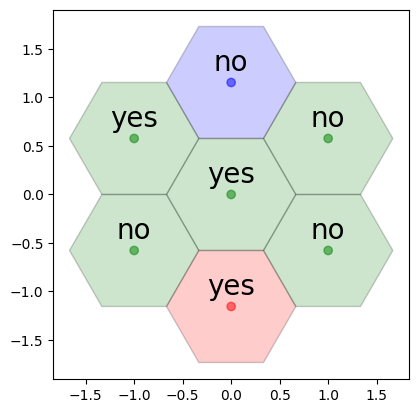

In [ ]:
# https://stackoverflow.com/a/46526761

import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np

coord = [[0,0,0],[0,1,-1],[-1,1,0],[-1,0,1],[0,-1,1],[1,-1,0],[1,0,-1]]
colors = [["Green"],["Blue"],["Green"],["Green"],["Red"],["Green"],["Green"]]
labels = [['yes'],['no'],['yes'],['no'],['yes'],['no'],['no']]

# Horizontal cartesian coords
hcoord = [c[0] for c in coord]

# Vertical cartersian coords
# y_cartesian = (2 / 3) * sin(60) * (y_hex - z_hex)
vcoord = [2. * np.sin(np.radians(60)) * (c[1] - c[2]) /3. for c in coord]

fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Add some coloured hexagons
for x, y, c, l in zip(hcoord, vcoord, colors, labels):
    color = c[0].lower()  # matplotlib understands lower case words for colours
    hex = RegularPolygon((x, y), numVertices=6, radius=2. / 3.,
                         orientation=np.radians(30),
                         facecolor=color, alpha=0.2, edgecolor='k')
    ax.add_patch(hex)
    # Also add a text label
    ax.text(x, y+0.2, l[0], ha='center', va='center', size=20)

# Also add scatter points in hexagon centres
ax.scatter(hcoord, vcoord, c=[c[0].lower() for c in colors], alpha=0.5)

plt.show()

In [ ]:
sdg_colors = [
    '#E5243B',  # SDG 1: No Poverty
    '#DDA63A',  # SDG 2: Zero Hunger
    '#4C9F38',  # SDG 3: Good Health and Well-being
    '#C5192D',  # SDG 4: Quality Education
    '#FF3A21',  # SDG 5: Gender Equality
    '#26BDE2',  # SDG 6: Clean Water and Sanitation
    '#FCC30B',  # SDG 7: Affordable and Clean Energy
    '#A21942',  # SDG 8: Decent Work and Economic Growth
    '#FD6925',  # SDG 9: Industry, Innovation and Infrastructure
    '#DD1367',  # SDG 10: Reduced Inequality
    '#FD9D24',  # SDG 11: Sustainable Cities and Communities
    '#BF8B2E',  # SDG 12: Responsible Consumption and Production
    '#3F7E44',  # SDG 13: Climate Action
    '#0A97D9',  # SDG 14: Life Below Water
    '#56C02B',  # SDG 15: Life on Land
    '#00689D',  # SDG 16: Peace, Justice and Strong Institutions
    '#19486A'   # SDG 17: Partnerships for the Goals
]

sdg_goal_values = [0.9165794559236699,
 0.6606572250642769,
 0.5217736472248115,
 0.3355571925918389,
 0.03369599193210713,
 0.48351173583997753,
 0.9078118360414676,
 0.42478601175590736,
 0.8847358764768378,
 0.18331059896979018,
 0.5694646129282523,
 0.9894812840563191,
 0.39324376591189414,
 0.4600025582328032,
 0.10116065228310345,
 0.2916807426644986,
 0.45870932592417324]

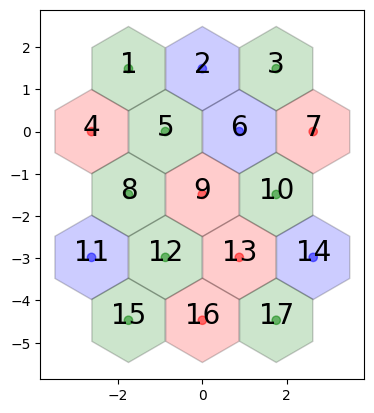

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np




# Updated axial coordinates for hexagons with tight spacing:
#   1  2  3
# 4  5  6  7
#   8  9 10
# 11 12 13 14
#   15 16 17

coord = [
    [-1, 1], [0, 1], [1, 1],  # Row 1: (1 2 3)
    [-1.5, 0], [-0.5, 0], [0.5, 0], [1.5, 0],  # Row 2: (4 5 6 7)
    [-1, -1], [0, -1], [1, -1],  # Row 3: (8 9 10)
    [-1.5, -2], [-0.5, -2], [0.5, -2], [1.5, -2],  # Row 4: (11 12 13 14)
    [-1, -3], [0, -3], [1, -3]  # Row 5: (15 16 17)
]

# Colors and labels for the grid
colors = [
    ["Green"], ["Blue"], ["Green"],  # Row 1
    ["Red"], ["Green"], ["Blue"], ["Red"],  # Row 2
    ["Green"], ["Red"], ["Green"],  # Row 3
    ["Blue"], ["Green"], ["Red"], ["Blue"],  # Row 4
    ["Green"], ["Red"], ["Green"]  # Row 5
]

labels = [
    ['1'], ['2'], ['3'],  # Row 1
    ['4'], ['5'], ['6'], ['7'],  # Row 2
    ['8'], ['9'], ['10'],  # Row 3
    ['11'], ['12'], ['13'], ['14'],  # Row 4
    ['15'], ['16'], ['17']  # Row 5
]

# Create the plot
fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Parameters for hexagon size and spacing
radius = 1  # Size of the hexagons
x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons

# Add hexagons to the plot with 0-degree orientation for flat tops
for (x, y), c, l in zip(coord, colors, labels):
    color = c[0].lower()  # Convert color to lowercase
    hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                         radius=radius, orientation=np.radians(0),
                         facecolor=color, alpha=0.2, edgecolor='k')
    ax.add_patch(hex)
    # Add text labels
    ax.text(x * x_spacing, y * y_spacing + 0.1, l[0], ha='center', va='center', size=20)

# Add scatter points to hexagon centers
ax.scatter([x * x_spacing for x, y in coord],
           [y * y_spacing for x, y in coord],
           c=[c[0].lower() for c in colors], alpha=0.5)

plt.show()


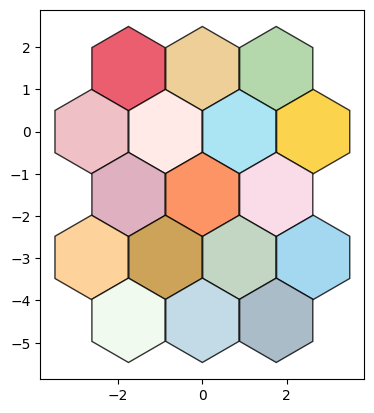

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np




# Updated axial coordinates for hexagons with tight spacing:
#   1  2  3
# 4  5  6  7
#   8  9 10
# 11 12 13 14
#   15 16 17

coord = [
    [-1, 1], [0, 1], [1, 1],  # Row 1: (1 2 3)
    [-1.5, 0], [-0.5, 0], [0.5, 0], [1.5, 0],  # Row 2: (4 5 6 7)
    [-1, -1], [0, -1], [1, -1],  # Row 3: (8 9 10)
    [-1.5, -2], [-0.5, -2], [0.5, -2], [1.5, -2],  # Row 4: (11 12 13 14)
    [-1, -3], [0, -3], [1, -3]  # Row 5: (15 16 17)
]

labels = [
    ['1'], ['2'], ['3'],  # Row 1
    ['4'], ['5'], ['6'], ['7'],  # Row 2
    ['8'], ['9'], ['10'],  # Row 3
    ['11'], ['12'], ['13'], ['14'],  # Row 4
    ['15'], ['16'], ['17']  # Row 5
]

# Create the plot
fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Parameters for hexagon size and spacing
radius = 1  # Size of the hexagons
x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons



# Add hexagons with color based on the value scaling between white (0) and SDG color (1)
for (x, y), value, color, label in zip(coord, sdg_goal_values, sdg_colors, labels):
    rgba_color = plt.cm.colors.to_rgba(color)  # Convert SDG color to RGBA
    blended_color = [1 - value + value * rgba for rgba in rgba_color]  # Blend with white
    hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                         radius=radius, orientation=np.radians(0),
                         facecolor=blended_color, alpha=0.8, edgecolor='k')
    ax.add_patch(hex)
    # Add text labels
    # ax.text(x * x_spacing, y * y_spacing + 0.1, label[0], ha='center', va='center', size=20)


# Add scatter points to hexagon centers
ax.scatter([x * x_spacing for x, y in coord],
           [y * y_spacing for x, y in coord],
           alpha=0.0)

plt.show()


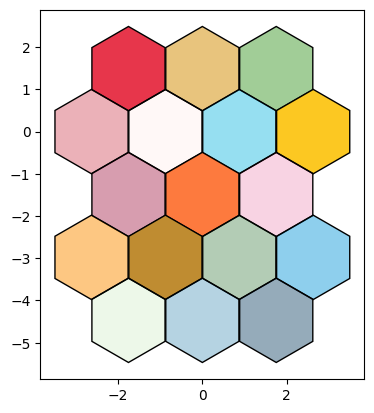

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np

# Updated axial coordinates for hexagons with tight spacing:
#   1  2  3
# 4  5  6  7
#   8  9 10
# 11 12 13 14
#   15 16 17

coord = [
    [-1, 1], [0, 1], [1, 1],  # Row 1: (1 2 3)
    [-1.5, 0], [-0.5, 0], [0.5, 0], [1.5, 0],  # Row 2: (4 5 6 7)
    [-1, -1], [0, -1], [1, -1],  # Row 3: (8 9 10)
    [-1.5, -2], [-0.5, -2], [0.5, -2], [1.5, -2],  # Row 4: (11 12 13 14)
    [-1, -3], [0, -3], [1, -3]  # Row 5: (15 16 17)
]

labels = [
    ['1'], ['2'], ['3'],  # Row 1
    ['4'], ['5'], ['6'], ['7'],  # Row 2
    ['8'], ['9'], ['10'],  # Row 3
    ['11'], ['12'], ['13'], ['14'],  # Row 4
    ['15'], ['16'], ['17']  # Row 5
]

# Create the plot
fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Parameters for hexagon size and spacing
radius = 1  # Size of the hexagons
x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons



# Add hexagons with color based on the value scaling from 0 (fully transparent) to 1 (fully SDG color)
for (x, y), value, color, label in zip(coord, sdg_goal_values, sdg_colors, labels):
    rgba_color = plt.cm.colors.to_rgba(color)  # Convert SDG color to RGBA
    rgba_color_with_alpha = (rgba_color[0], rgba_color[1], rgba_color[2], value)  # Adjust alpha (transparency)

    hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                         radius=radius, orientation=np.radians(0),
                         facecolor=rgba_color_with_alpha, edgecolor='k')

    ax.add_patch(hex)


# Add scatter points to hexagon centers
ax.scatter([x * x_spacing for x, y in coord],
           [y * y_spacing for x, y in coord],
           alpha=0.0)

plt.show()


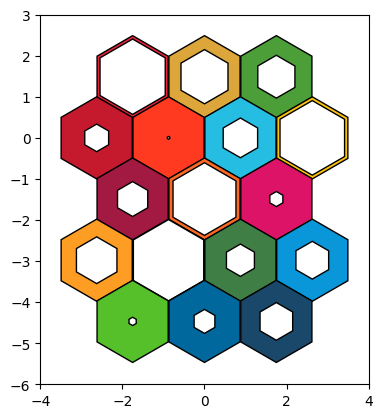

In [ ]:
# Create the plot
fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Parameters for hexagon size and spacing
radius = 1  # Size of the hexagons
x_spacing = radius * 1.75  # Horizontal distance between centers of adjacent hexagons
y_spacing = np.sqrt(3) * radius * 0.86  # Vertical distance between centers of hexagons

# Add hexagons with color based on the value scaling from 0 (fully transparent) to 1 (fully SDG color)
for (x, y), value, color, label in zip(coord, sdg_goal_values, sdg_colors, labels):
    rgba_color = plt.cm.colors.to_rgba(color)  # Convert SDG color to RGBA

    # Outer hexagon for the full SDG color
    outer_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                               radius=radius, orientation=np.radians(0),
                               facecolor=rgba_color, edgecolor='k')

    ax.add_patch(outer_hex)

    # Inner hexagon for the percentage fill
    inner_radius = value * radius  # Scale inner radius based on the value
    inner_hex = RegularPolygon((x * x_spacing, y * y_spacing), numVertices=6,
                               radius=inner_radius, orientation=np.radians(0),
                               facecolor='white', edgecolor='k')  # White color for the inner hexagon

    ax.add_patch(inner_hex)

# Add labels to the hexagons
#for (x, y), label in zip(coord, labels):
#    ax.text(x * x_spacing, y * y_spacing, label[0],
#            horizontalalignment='center', verticalalignment='center')

plt.xlim(-4, 4)
plt.ylim(-6, 3)
plt.show()

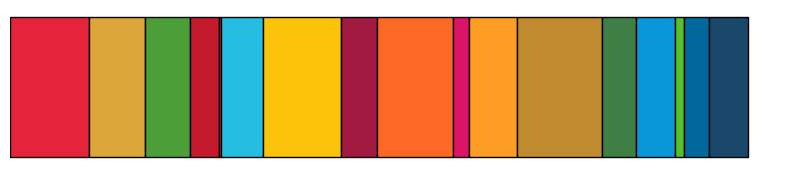

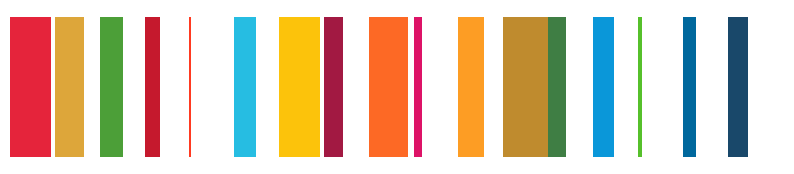

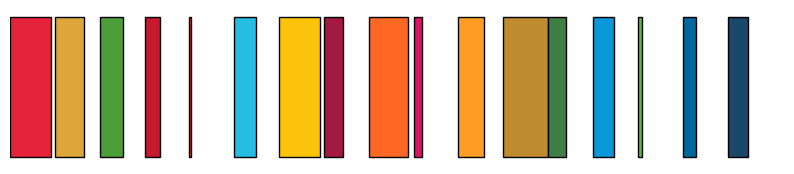

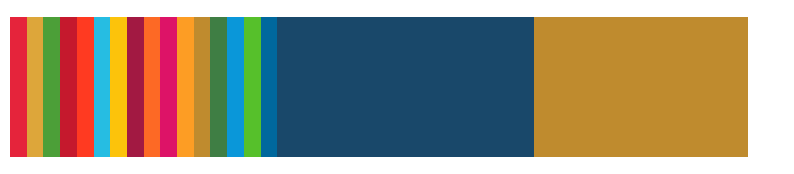

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Barcode visualization function with squeezing option and white space
def plot_barcode(goal_values, colors, length=1, with_lines=False, scaled=False, squeeze=False):
    fig, ax = plt.subplots(figsize=(10, 2))

    total_length = 17.0 * length  # Full length is 17 * 1.0
    start = 0

    # If squeeze is True, total bar length is determined by sum of values
    total_value_length = sum(goal_values) if squeeze else total_length

    for i, value in enumerate(goal_values):
        # If scaled, scale the bars, otherwise control by squeeze
        bar_length = value if scaled else value * length / total_value_length

        # Draw the colored part of the bar
        ax.barh(0, bar_length, left=start, height=0.5, color=colors[i], edgecolor='black' if with_lines else None)

        # Move the start position for the next bar
        start += bar_length if scaled else (length / total_length)

    # Set axis off to hide details
    ax.set_axis_off()

    plt.show()

# Example usage:
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=True, scaled=True)    # Scaled to the left
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=False, scaled=False)  # Full length with white space
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=True, scaled=False)   # Full length with white space
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=False, scaled=False, squeeze=True)  # Stacked bar


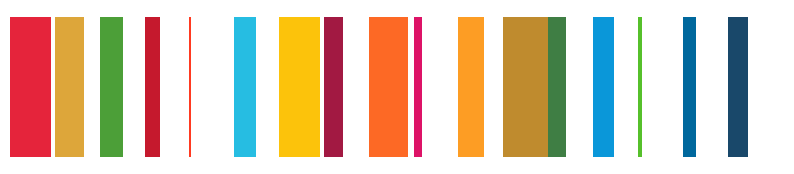

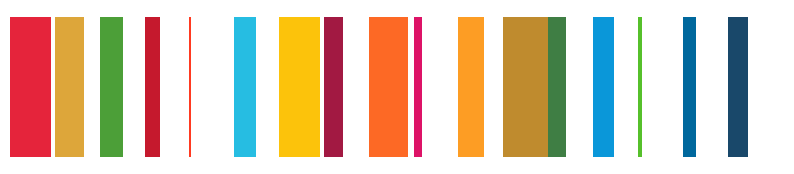

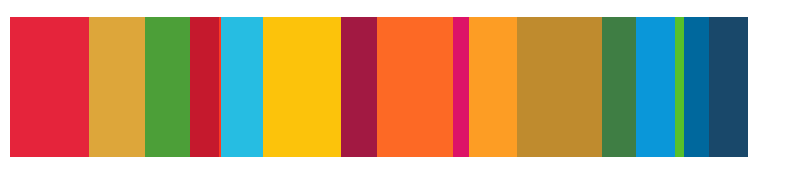

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Barcode visualization function with squeezing option and white space
def plot_barcode(goal_values, colors, length=17.0, with_lines=False, scaled=False, squeeze=False):
    fig, ax = plt.subplots(figsize=(10, 2))

    # Calculate total length if squeeze is applied
    total_value_length = length

    # Set bar width for non-squeeze mode (default 1/17th of total length)
    bar_width = length / 17.0

    start = 0  # Position where the next bar should start

    for i, value in enumerate(goal_values):
        # Calculate the length of each bar
        if scaled:
            bar_length = value * length / total_value_length
        else:
            bar_length = bar_width * value

        # Draw the colored part of the bar
        ax.barh(0, bar_length, left=start, height=0.5, color=colors[i], edgecolor='black' if with_lines else None)

        # Add vertical lines between bars if needed (not in squeeze mode)
        if with_lines:
            ax.vlines(start + bar_length, -0.25, 0.25, colors='black')

        # Move the start position for the next bar
        if squeeze:
          start += bar_length
        else:
          start += bar_width


    # Set axis off to hide details
    ax.set_axis_off()

    plt.show()



# Different modes of visualization:
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=False, scaled=False, squeeze=False)  # Default, full length
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=False, scaled=True, squeeze=False)   # Scaled to goal values
plot_barcode(sdg_goal_values, sdg_colors, length=17, with_lines=False, scaled=False, squeeze=True)  # Squeezed mode without white space


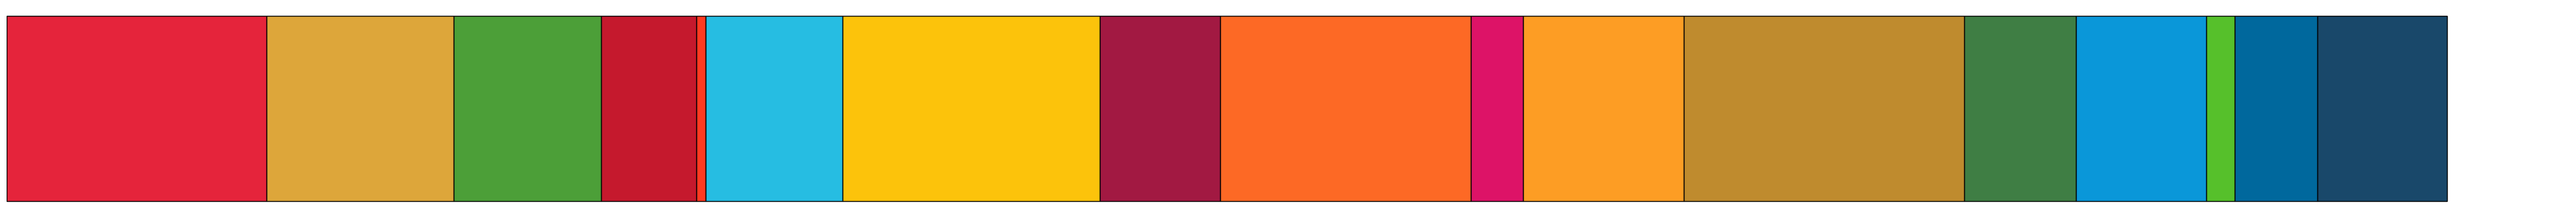

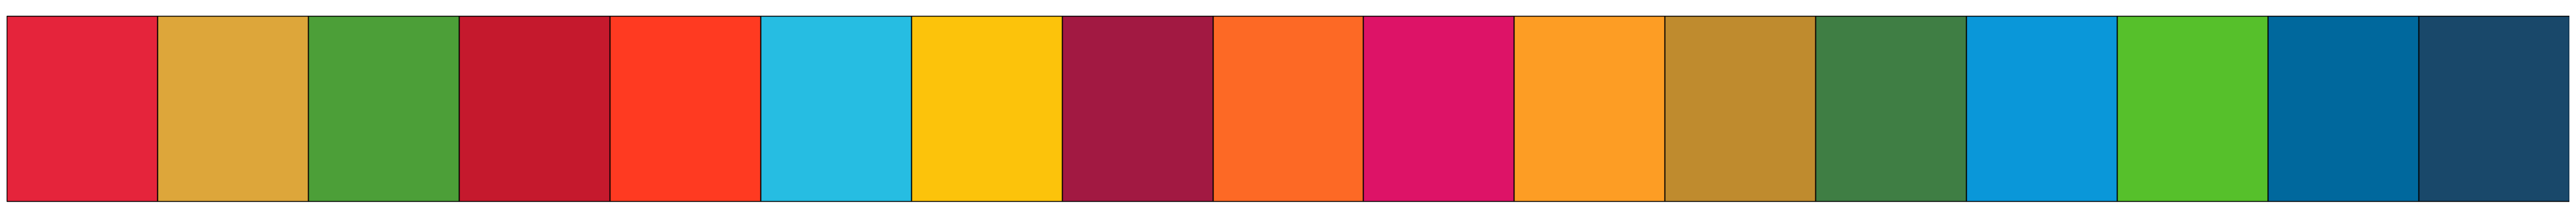

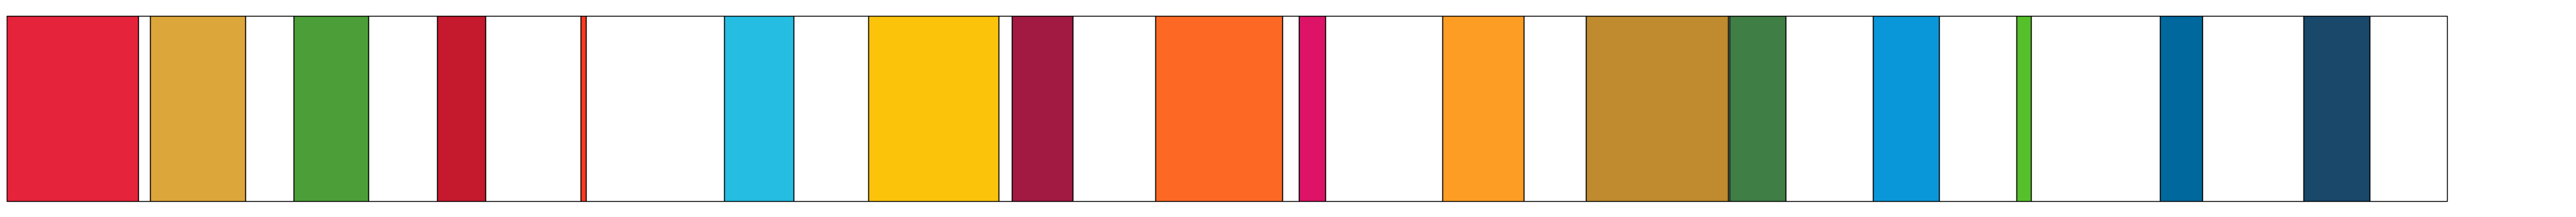

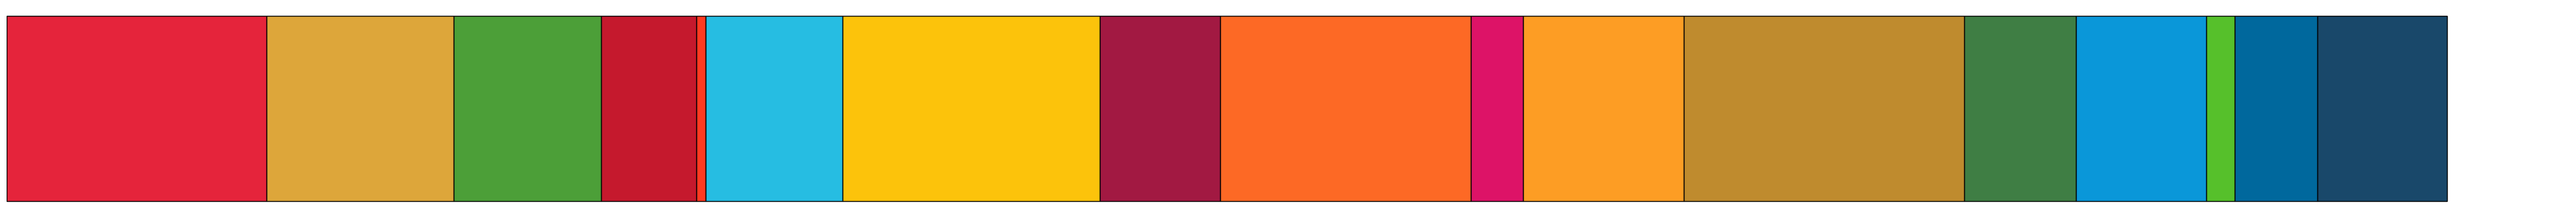

In [ ]:
# Barcode visualization function with squeezing option and white space
def plot_barcode(goal_values, colors, segmented=False, stacked=False):
    fig, ax = plt.subplots(figsize=(50, 4))

    with_lines = True


    if segmented:
        if stacked:
          start = 0  # Position where the next bar should start
          for i, value in enumerate(goal_values):
            bar_width = 1*value
            ax.barh(0, bar_width, left=start, height=0.5, color=colors[i], edgecolor='black' if with_lines else None)
            start += bar_width
        elif not stacked:
          start = 0  # Position where the next bar should start
          for i, value in enumerate(goal_values):
            bar_width = 1*value
            ax.barh(0, bar_width, left=start, height=0.5, color=colors[i], edgecolor='black' if with_lines else None)
            start += bar_width
            bar_width = (1-value)
            ax.barh(0, bar_width, left=start, height=0.5, color='white', edgecolor='black' if with_lines else None)
            start += bar_width
    if not segmented:
      start = 0  # Position where the next bar should start
      for i, value in enumerate(goal_values):
        bar_width = 1*value
        ax.barh(0, bar_width, left=start, height=0.5, color=colors[i], edgecolor='black' if with_lines else None)
        start += bar_width

    # Set axis off to hide details
    ax.set_axis_off()

    plt.show()

scale = [1 for i in range (1,18,1)]
plot_barcode(sdg_goal_values, sdg_colors, False)
plot_barcode(scale, sdg_colors, True, False)
plot_barcode(sdg_goal_values, sdg_colors, True, False)
plot_barcode(sdg_goal_values, sdg_colors, True, True)

In [ ]:
# TO update the title